# Лабораторная работа
## Физические adversarial-атаки: adversarial patches, дорожные знаки, состязательная одежда

### Паспорт работы

| Поле | Значение |
|---|---|
| ФИО студента | |
| Группа | |
| Дата выполнения | |
| Номер варианта | 1 |
| Значение `SEED` (см. таблицу вариантов) | 42 (`RES = 16`, `FREQ = 1.5`, углы 0–32° с шагом 8°) |
| Преподаватель | |

### Таблица вариантов

| Вариант | `SEED` | Разрешение `RES` | Частота складок `FREQ` | Дополнительное условие части E |
|---|---|---|---|---|
| 1 | 42 | 16 | 1.5 | углы 0–32° с шагом 8° |
| 2 | 7 | 16 | 2.0 | углы 0–40° с шагом 10° |
| 3 | 123 | 20 | 1.5 | углы 0–24° с шагом 6° |
| 4 | 2024 | 20 | 2.2 | углы 0–32° с шагом 8° |
| 5 | 314 | 12 | 1.2 | углы 0–40° с шагом 10° |
| 6 | 555 | 24 | 1.8 | углы 0–24° с шагом 6° |

> Вариант выдаётся преподавателем. Все числовые результаты в отчёте должны соответствовать
> **вашему** варианту, а не значениям из примера.

### Цель работы

Экспериментально исследовать, почему устойчивость модели компьютерного зрения к физическим
adversarial-атакам не определяется её точностью на цифровых изображениях, и оценить
эффективность базовых защитных мер.

### Задачи

1. Построить учебный стенд компьютерного зрения и измерить базовую точность.
2. Реализовать имитацию физического канала наблюдения и оценить влияние отдельных факторов съёмки.
3. Исследовать локальность патча: зависимость деградации от площади и положения области.
4. Применить логику Expectation over Transformation при оценке устойчивости.
5. Построить карту качества жёсткого объекта в координатах «дистанция × ракурс».
6. Смоделировать не-жёсткие деформации ткани и сравнить их с жёстким преобразованием.
7. Обучить модель с физически правдоподобными аугментациями и оценить прирост устойчивости.
8. Проверить эффект временной агрегации решений по кадрам.
9. Сформулировать выводы и заполнить сводную таблицу отчёта.

### Ограничение

Работа выполняется **только** на синтетическом учебном наборе и локальных моделях. Запрещается
использовать код работы для воздействия на реальные системы восприятия, камеры, внешние сервисы
и любые эксплуатируемые объекты. Печатаемые атакующие шаблоны в работе не создаются.

## Краткая теория

Физическая атака изменяет **объект в сцене**, а не входной тензор модели. Наблюдение описывается как

\[
x_{\text{cam}} = T_\theta\big(x \odot (1 - M) + p \odot M\big), \qquad \theta \sim \mathcal{D}_{\text{физ}},
\]

где \(M\) — маска области патча, \(p\) — его содержимое, \(T_\theta\) — преобразование при параметрах
съёмки \(\theta\) (ракурс, дистанция, освещение, оптика, обработка изображения).

Требование робастности возмущения формализует Expectation over Transformation:

\[
\max_{p}\; \mathbb{E}_{\theta \sim \mathcal{D}}\Big[\mathcal{L}\big(f(T_\theta(x, p, M)),\, y_{\text{target}}\big)\Big].
\]

**Задание 0.** Таблица различий трёх постановок:

| Признак | Цифровое возмущение | Патч на жёстком знаке | Состязательная одежда |
|---|---|---|---|
| Что изменяется | Входной тензор модели: значения пикселей после камеры | Участок поверхности жёсткого объекта (наклейка, краска) до съёмки | Рисунок на ткани, которая движется и деформируется вместе с человеком |
| Ограничение возмущения | Малая норма $\|\delta\|_p \le \varepsilon$ по всему изображению | Не норма, а маска $M$: ограничены площадь и положение, содержимое внутри может быть любым; плюс печатаемость цветов | Маска на одежде, печатаемость, плюс ограничения ткани: гибкость, растяжимость, естественный вид |
| Обязательные члены $\mathcal{D}$ | Не нужны: канал наблюдения отсутствует | Ракурс, дистанция (масштаб), освещение, размытие, шум сенсора, частичная окклюзия | Всё то же, что для знака, плюс складки, растяжение, смена позы, самоокклюзия, динамика движения |
| Основная сложность | Минимальная: прямой доступ к градиенту по входу | Устойчивость к изменению условий съёмки и к малой видимой площади на расстоянии | Непредсказуемые не-жёсткие деформации: рисунок каждый раз искажается по-разному |
| Типичная метрика | ASR при фиксированном $\varepsilon$ | Robust ASR / точность, усреднённая по распределению условий (ракурс × дистанция) | Снижение доли детекций (recall / AP детектора людей) по видео и разным позам |

## Часть A. Стенд компьютерного зрения и базовая модель

Код подготовки данных дан полностью. **Ваша задача** — задать параметры своего варианта
и объяснить полученную точность.

In [ ]:
# A.1: параметры варианта 1
SEED = 42
RES = 16
FREQ = 1.5

assert SEED is not None and RES is not None and FREQ is not None, "Задайте параметры варианта"

RES = 16×16 | обучающая: 1257 | тестовая: 540
A.2 Базовая точность на неискажённых изображениях: 0.943


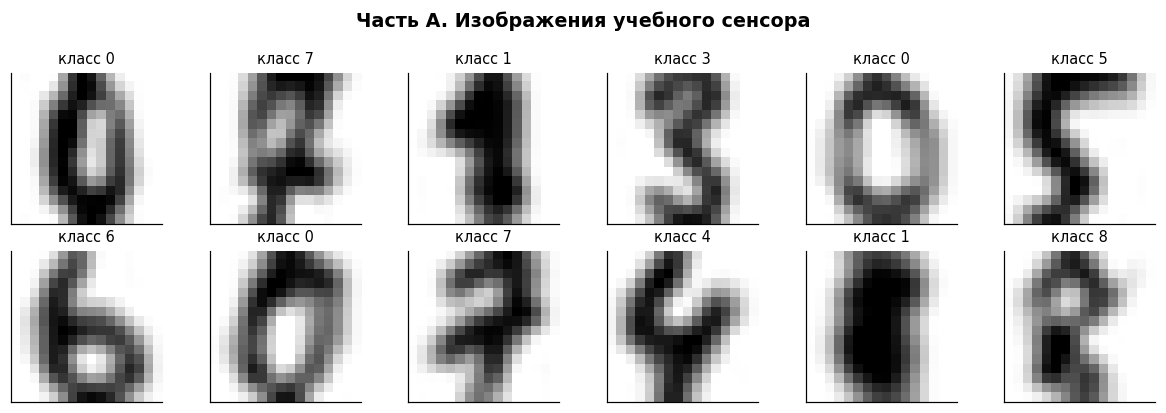

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.ndimage import rotate, zoom, gaussian_filter, map_coordinates

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

rng = np.random.default_rng(SEED)

mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
PALETTE = {"clean": "#2E86AB", "mild": "#F2A541", "severe": "#D6455F",
           "robust": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list("acc", ["#7F1338", "#D6455F", "#F2A541", "#F7E463", "#3FA46A"])
CMAP_PATCH = ListedColormap(["#00B8A9"])


def show_img(ax, image, title=None):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=9.5, fontweight="normal")


digits = load_digits()
raw = digits.images.astype(np.float32) / 16.0
images = np.clip(np.asarray([gaussian_filter(zoom(im, RES / 8.0, order=3), 0.6) for im in raw]), 0, 1).astype(np.float32)
labels = digits.target

X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED)


def flat(arr3d):
    return np.asarray(arr3d).reshape(len(arr3d), -1)


# Признаки — интенсивности пикселей в [0, 1]; масштабирование по дисперсии не применяется,
# иначе всегда нулевые краевые пиксели дают численные артефакты при сдвиге условий съёмки.
baseline = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_train_img), y_train)
acc_clean = accuracy_score(y_test, baseline.predict(flat(X_test_img)))
print(f"RES = {RES}×{RES} | обучающая: {len(X_train_img)} | тестовая: {len(X_test_img)}")
print(f"A.2 Базовая точность на неискажённых изображениях: {acc_clean:.3f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.8))
for ax, im, lb in zip(axes.ravel(), X_train_img[:12], y_train[:12]):
    show_img(ax, im, f"класс {lb}")
fig.suptitle("Часть A. Изображения учебного сенсора", fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

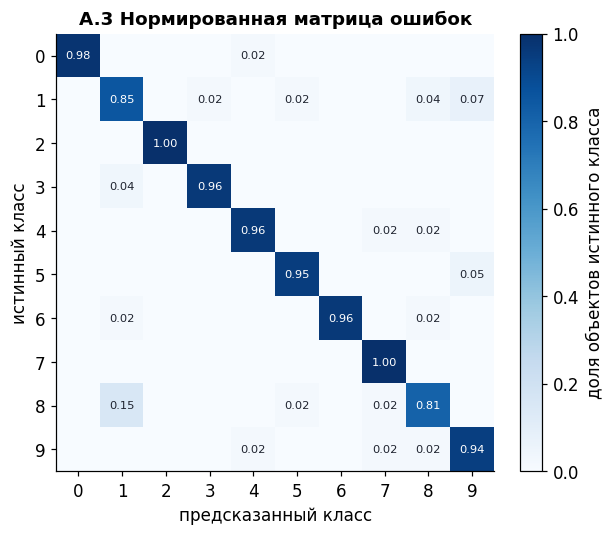

Путаница 1 ↔ 8: 0.036 + 0.154 = 0.190
Путаница 1 ↔ 9: 0.073 + 0.000 = 0.073


In [ ]:
# A.3: нормированная матрица ошибок базовой модели
y_pred_clean = baseline.predict(flat(X_test_img))
cm = confusion_matrix(y_test, y_pred_clean, normalize="true")

fig, ax = plt.subplots(figsize=(5.8, 5.0))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("предсказанный класс"); ax.set_ylabel("истинный класс"); ax.grid(False)
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0.005:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if cm[i, j] > 0.5 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.046, label="доля объектов истинного класса")
ax.set_title("A.3 Нормированная матрица ошибок")
plt.tight_layout(); plt.show()

# две пары с наибольшей путаницей (симметричная сумма ошибок в обе стороны)
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted(((off[i, j] + off[j, i], i, j) for i in range(10) for j in range(i + 1, 10)), reverse=True)[:2]
for v, i, j in pairs:
    print(f"Путаница {i} ↔ {j}: {off[i, j]:.3f} + {off[j, i]:.3f} = {v:.3f}")

**Отчёт по части A.**

| Показатель | Значение |
|---|---|
| `SEED` / `RES` | 42 / 16 (вариант 1) |
| Размер обучающей выборки | 1257 изображений (тестовая — 540) |
| Базовая точность `acc_clean` | **0.943** |
| Две пары классов с наибольшей путаницей | **1 ↔ 8**: 15.4 % восьмёрок распознаются как 1, 3.6 % единиц как 8 (сумма 0.190); **1 ↔ 9**: 7.3 % единиц распознаются как 9 (сумма 0.073) |

**Вопрос A.** Можно ли по значению `acc_clean` судить о пригодности модели для работы с физическими объектами?

Ответ: **нет**. Точность 0.943 измерена на тех же условиях, в которых модель обучалась: объекты отцентрированы, одинакового масштаба, при ровном освещении, без размытия и шума. Физический мир даёт другое распределение входов. Уже в этой работе при умеренных условиях съёмки точность падает до 0.739, при сильных — до 0.485 (часть D), а на краю карты «дистанция × ракурс» — до 0.106 (часть E), хотя модель и объекты те же самые. `acc_clean` — это оценка в одной точке распределения условий, тогда как пригодность определяется поведением **по всему распределению** $\mathcal{D}_{\text{физ}}$. Показательна и матрица ошибок: наиболее уязвимы пары классов с похожей формой (1/8, 1/9), и именно они первыми «перепутаются» при повороте или размытии.

## Часть B. Имитация физического канала

Функция `resize_to_shape` дана. **Ваша задача** — дописать `physical_transform`: реализовать
изменение яркости и контраста, размытие, шум сенсора и окклюзию.

In [ ]:
def resize_to_shape(image, shape):
    out = np.zeros(shape, dtype=np.float32)
    h = min(shape[0], image.shape[0]); w = min(shape[1], image.shape[1])
    ts, ls = max((image.shape[0] - h) // 2, 0), max((image.shape[1] - w) // 2, 0)
    td, ld = max((shape[0] - h) // 2, 0), max((shape[1] - w) // 2, 0)
    out[td:td + h, ld:ld + w] = image[ts:ts + h, ls:ls + w]
    return out

In [ ]:
def physical_transform(image, angle=0.0, scale=1.0, brightness=1.0, contrast=1.0,
                       blur=0.0, noise=0.0, occlusion=None, generator=None):
    """Имитация физического канала наблюдения объекта камерой."""
    gen = generator if generator is not None else rng

    # поворот и масштаб
    out = rotate(image, angle=angle, reshape=False, order=1, mode="constant", cval=0.0)
    if abs(scale - 1.0) > 1e-6:
        out = resize_to_shape(zoom(out, scale, order=1), image.shape)

    # B.1: контраст относительно середины диапазона
    out = (out - 0.5) * contrast + 0.5
    # B.2: яркость (освещённость сцены)
    out = out * brightness
    # B.3: размытие оптики (расфокусировка, смаз)
    if blur > 0:
        out = gaussian_filter(out, sigma=blur)
    # B.4: шум сенсора
    if noise > 0:
        out = out + gen.normal(0.0, noise, out.shape)
    # B.5: окклюзия (r0, r1, c0, c1, value)
    if occlusion is not None:
        r0, r1, c0, c1, value = occlusion
        out = out.copy()
        out[r0:r1, c0:c1] = value

    return np.clip(out, 0.0, 1.0).astype(np.float32)

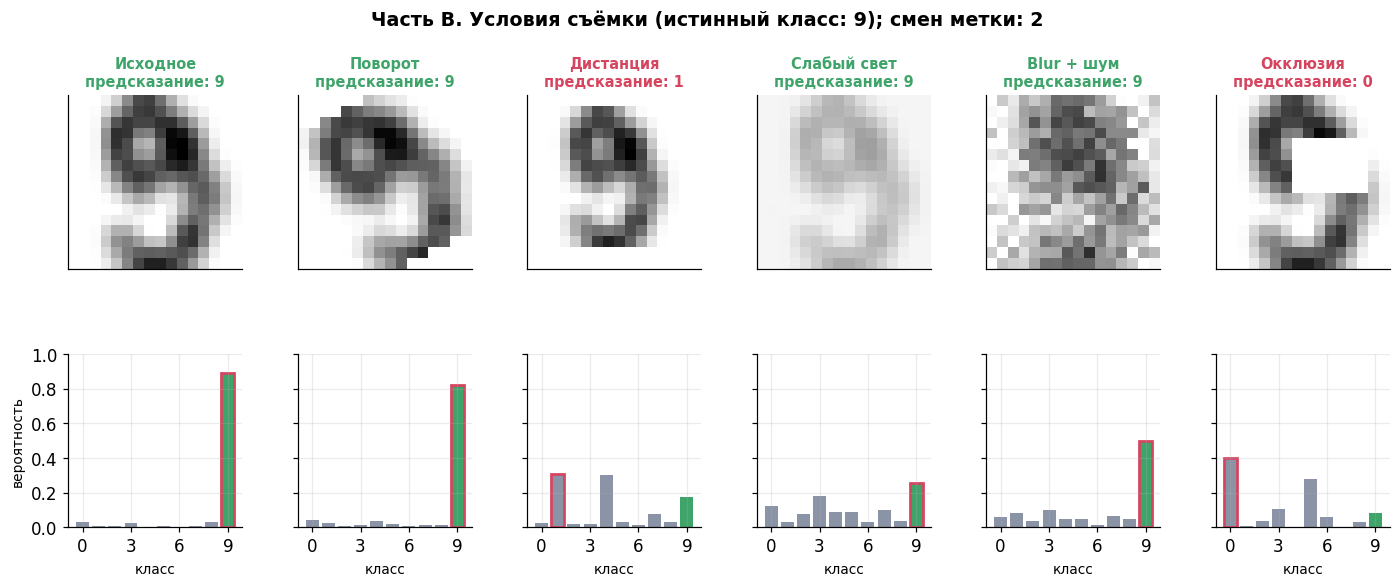

B.7 Число режимов со сменой метки: 2 (требуется не менее 2)


In [ ]:
# B.6: объект-пример и параметры режимов; стартовые значения уже дают две смены метки (см. B.7)
idx = 9
example, true_label = X_test_img[idx], y_test[idx]

conditions = [
    ("Исходное",        dict()),
    ("Поворот",         dict(angle=26)),
    ("Дистанция",       dict(scale=0.80)),
    ("Слабый свет",     dict(brightness=0.42, contrast=0.80)),
    ("Blur + шум",      dict(blur=1.7, noise=0.13)),
    ("Окклюзия",        dict(occlusion=(RES // 4, RES // 4 + RES // 3, RES // 2 - 1, RES - 2, 0.0))),
]

fig, axes = plt.subplots(2, len(conditions), figsize=(15.5, 5.4),
                         gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.30, "wspace": 0.32})
flips = 0
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba)); ok = pred == true_label
    flips += (not ok)
    show_img(axes[0, col], view)
    axes[0, col].set_title(f"{name}\nпредсказание: {pred}", fontsize=9.5, fontweight="bold",
                           color=PALETTE["robust"] if ok else PALETTE["severe"])
    bars = axes[1, col].bar(range(10), proba,
                           color=[PALETTE["robust"] if k == true_label else PALETTE["gray"] for k in range(10)])
    bars[pred].set_edgecolor(PALETTE["severe"]); bars[pred].set_linewidth(1.8)
    axes[1, col].set_ylim(0, 1); axes[1, col].set_xticks(range(0, 10, 3))
    axes[1, col].set_xlabel("класс", fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel("вероятность", fontsize=9)
    else:
        axes[1, col].set_yticklabels([])
fig.suptitle(f"Часть B. Условия съёмки (истинный класс: {true_label}); смен метки: {flips}",
             fontsize=12.5, fontweight="bold")
plt.show()
print(f"B.7 Число режимов со сменой метки: {flips} (требуется не менее 2)")

In [ ]:
# Таблица части B: значения для отчёта
rows = []
for col, (name, params) in enumerate(conditions):
    view = physical_transform(example, **params, generator=np.random.default_rng(SEED + col))
    proba = baseline.predict_proba(flat(view[None, ...]))[0]
    pred = int(np.argmax(proba))
    rows.append((name, pred, proba[true_label], pred != true_label))
print(f"{'Режим':<14}{'предсказание':>13}{'P(истинный)':>13}{'смена':>8}")
for name, pred, p, fl in rows:
    print(f"{name:<14}{pred:>13}{p:>13.3f}{('да' if fl else 'нет'):>8}")

Режим          предсказание  P(истинный)   смена
Исходное                  9        0.890     нет
Поворот                   9        0.824     нет
Дистанция                 1        0.173      да
Слабый свет               9        0.254     нет
Blur + шум                9        0.501     нет
Окклюзия                  0        0.080      да


In [ ]:
# Вопрос B, вторая часть: тот же набор режимов для нескольких других объектов
other_ids = [0, 3, 17, 42, 101]
print("индекс/класс | " + " | ".join(n for n, _ in conditions[1:]))
flip_counts = np.zeros(len(conditions) - 1, dtype=int)
for oid in other_ids:
    ex, tl = X_test_img[oid], y_test[oid]
    marks = []
    for col, (name, params) in enumerate(conditions[1:], start=1):
        v = physical_transform(ex, **params, generator=np.random.default_rng(SEED + col))
        pr = int(baseline.predict(flat(v[None, ...]))[0])
        marks.append(f"{pr}{'✗' if pr != tl else '✓'}")
        flip_counts[col - 1] += pr != tl
    print(f"{oid:>4} / {tl}      | " + " | ".join(marks))
print("смен метки по режимам:", dict(zip([n for n, _ in conditions[1:]], flip_counts.tolist())))

индекс/класс | Поворот | Дистанция | Слабый свет | Blur + шум | Окклюзия
   0 / 1      | 6✗ | 4✗ | 5✗ | 1✓ | 2✗
   3 / 5      | 5✓ | 5✓ | 5✓ | 5✓ | 5✓
  17 / 7      | 4✗ | 7✓ | 7✓ | 7✓ | 7✓
  42 / 1      | 9✗ | 1✓ | 9✗ | 9✗ | 5✗
 101 / 0      | 0✓ | 4✗ | 0✓ | 2✗ | 0✓
смен метки по режимам: {'Поворот': 3, 'Дистанция': 2, 'Слабый свет': 2, 'Blur + шум': 2, 'Окклюзия': 2}


**Отчёт по части B.** Объект-пример: тестовый индекс 9, истинный класс 9. Параметры режимов оставлены стартовыми: они уже дают требуемые две смены метки.

| Режим | Предсказание | Вероятность истинного класса | Метка изменилась? |
|---|---|---|---|
| Исходное | 9 | 0.890 | нет |
| Поворот (26°) | 9 | 0.824 | нет |
| Дистанция (×0.80) | 1 | 0.173 | **да** |
| Слабый свет (яркость 0.42, контраст 0.80) | 9 | 0.254 | нет |
| Blur + шум (σ 1.7, шум 0.13) | 9 | 0.501 | нет |
| Окклюзия | 0 | 0.080 | **да** |

**Вопрос B.** Какой фактор оказался наиболее разрушительным и почему? Отличается ли ответ для другого объекта?

Ответ: для этой девятки наиболее разрушительна **окклюзия**: вероятность истинного класса упала до 0.080, модель выдала 0. Окно закрыло правую часть цифры, где у девятки проходит вертикальный штрих и замыкается петля, то есть уничтожило именно тот участок, который отличает 9 от 0. Второй по силе фактор — **дистанция** (0.173, предсказание 1): при уменьшении масштаба цифра сжимается к центру, и её пиксели попадают в те позиции, которые логистическая регрессия связывает с тонкой вертикальной единицей. Слабый свет сильно снизил уверенность (0.254), но метку не сменил: пропорциональное затемнение сохраняет **форму** изображения, а линейная модель сравнивает прежде всего относительные веса пикселей.

Для других объектов ответ **другой** (дополнительная таблица выше). Единица (индекс 0) ломается в 4 режимах из 5, девятка (индекс 42) — тоже в 4, а пятёрка (индекс 3) выдерживает все пять режимов. По пяти объектам чаще всего метку меняет поворот (3 случая из 5), остальные режимы — по 2. Вывод: «самый опасный фактор» — свойство пары «объект + модель», а не фактора самого по себе. Поэтому оценка устойчивости по одному примеру ненадёжна, и в части D она заменяется усреднением по выборке и по распределению условий.

## Часть C. Локальный патч: площадь и положение

**Ваша задача** — реализовать наложение локального маркера, построить карту точности по позициям
и кривую деградации по занимаемой площади.

> В работе используется **нейтральный маркер**, а не оптимизированный патч: исследуется структура
> ограничения (маска, площадь, положение), а не создание атакующего шаблона.

In [ ]:
def apply_marker(image, top=0, left=0, size=None, value=0.9):
    """Возвращает (изображение с маркером, бинарную маску маркера)."""
    if size is None:
        size = max(3, RES // 3)
    result = np.array(image, dtype=np.float32, copy=True)
    mask = np.zeros_like(result, dtype=np.float32)
    if size > 0:
        result[top:top + size, left:left + size] = value
        mask[top:top + size, left:left + size] = 1.0
    return result, mask

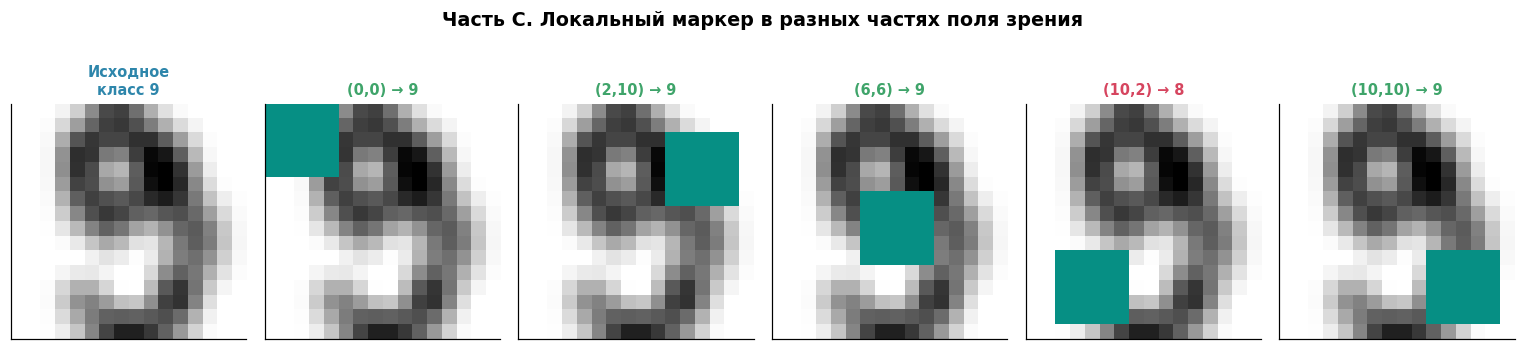

In [ ]:
MARKER = max(3, RES // 3)   # сторона маркера
positions = [(0, 0), (2, RES - MARKER - 1), (RES // 2 - 2, RES // 2 - 2),
             (RES - MARKER - 1, 2), (RES - MARKER - 1, RES - MARKER - 1)]

fig, axes = plt.subplots(1, len(positions) + 1, figsize=(14, 2.9))
show_img(axes[0], example)
axes[0].set_title(f"Исходное\nкласс {true_label}", fontsize=9.5, fontweight="bold", color=PALETTE["clean"])
for ax, (top, left) in zip(axes[1:], positions):
    marked, mask = apply_marker(example, top, left, MARKER)
    pred = int(baseline.predict(flat(marked[None, ...]))[0])
    show_img(ax, marked)
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=CMAP_PATCH, vmin=0, vmax=1,
              alpha=0.75, interpolation="nearest")
    ax.set_title(f"({top},{left}) → {pred}", fontsize=9.5, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть C. Локальный маркер в разных частях поля зрения",
             fontsize=12.5, fontweight="bold", y=1.10)
plt.tight_layout()
plt.show()

In [ ]:
stride = max(1, RES // 8)
grid_pos = list(range(0, RES - MARKER + 1, stride))
pos_map = np.zeros((len(grid_pos), len(grid_pos)))
for i, r in enumerate(grid_pos):
    for j, c in enumerate(grid_pos):
        marked = np.asarray([apply_marker(im, r, c, MARKER)[0] for im in X_test_img])
        pos_map[i, j] = accuracy_score(y_test, baseline.predict(flat(marked)))

# кривая по площади: квадратный маркер размещается в центре кадра
sizes = [0, RES // 8, RES // 5, RES // 4, RES // 3, RES // 2, int(RES * 0.7)]
area_acc, area_frac = [], []
for s in sizes:
    top = left = max(0, (RES - s) // 2)
    marked = np.asarray([apply_marker(im, top, left, s)[0] for im in X_test_img])
    area_acc.append(accuracy_score(y_test, baseline.predict(flat(marked))))
    area_frac.append(100.0 * s * s / RES ** 2)
for s, f, a in zip(sizes, area_frac, area_acc):
    print(f"сторона {s:>2}: площадь {f:5.1f} % → accuracy {a:.3f}")

сторона  0: площадь   0.0 % → accuracy 0.943
сторона  2: площадь   1.6 % → accuracy 0.941
сторона  3: площадь   3.5 % → accuracy 0.922
сторона  4: площадь   6.2 % → accuracy 0.831
сторона  5: площадь   9.8 % → accuracy 0.785
сторона  8: площадь  25.0 % → accuracy 0.422
сторона 11: площадь  47.3 % → accuracy 0.189


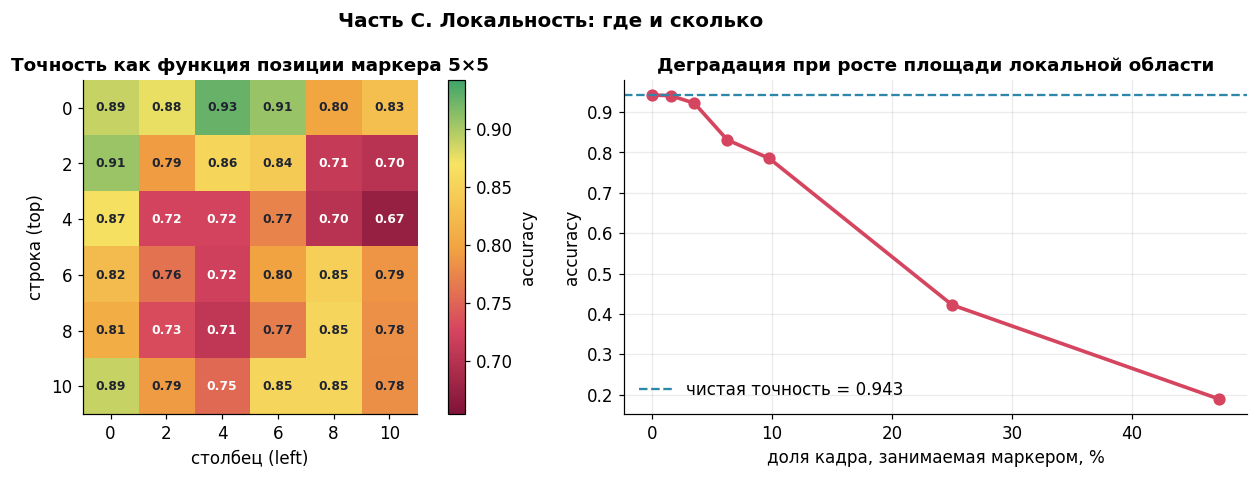

C.4 Худшая позиция: (4, 10) → accuracy 0.674
C.5 Лучшая позиция: accuracy 0.926; разница 0.252


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
im = axes[0].imshow(pos_map, cmap=CMAP_HEAT, vmin=pos_map.min() - 0.02, vmax=acc_clean)
axes[0].set_title(f"Точность как функция позиции маркера {MARKER}×{MARKER}")
axes[0].set_xlabel("столбец (left)"); axes[0].set_ylabel("строка (top)"); axes[0].grid(False)
axes[0].set_xticks(range(len(grid_pos))); axes[0].set_xticklabels(grid_pos)
axes[0].set_yticks(range(len(grid_pos))); axes[0].set_yticklabels(grid_pos)
for i in range(pos_map.shape[0]):
    for j in range(pos_map.shape[1]):
        axes[0].text(j, i, f"{pos_map[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     fontweight="bold", color="white" if pos_map[i, j] < 0.76 else "#1F2430")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="accuracy")

axes[1].plot(area_frac, area_acc, "o-", color=PALETTE["severe"], linewidth=2.4, markersize=7)
axes[1].axhline(acc_clean, ls="--", color=PALETTE["clean"], label=f"чистая точность = {acc_clean:.3f}")
axes[1].set_xlabel("доля кадра, занимаемая маркером, %"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Деградация при росте площади локальной области")
axes[1].legend(frameon=False)
fig.suptitle("Часть C. Локальность: где и сколько", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

worst = np.unravel_index(np.argmin(pos_map), pos_map.shape)
print(f"C.4 Худшая позиция: ({grid_pos[worst[0]]}, {grid_pos[worst[1]]}) → accuracy {pos_map.min():.3f}")
print(f"C.5 Лучшая позиция: accuracy {pos_map.max():.3f}; разница {pos_map.max() - pos_map.min():.3f}")

In [ ]:
best = np.unravel_index(np.argmax(pos_map), pos_map.shape)
print(f"Лучшая позиция: ({grid_pos[best[0]]}, {grid_pos[best[1]]}) → accuracy {pos_map.max():.3f}")
below = [f for f, a in zip(area_frac, area_acc) if a < 0.5]
print("Первая площадь с accuracy < 0.5:", f"{below[0]:.1f} %" if below else "не достигнута")
# линейная интерполяция точки пересечения уровня 0.5
for k in range(1, len(area_acc)):
    if area_acc[k - 1] >= 0.5 > area_acc[k]:
        f0, f1, a0, a1 = area_frac[k - 1], area_frac[k], area_acc[k - 1], area_acc[k]
        print(f"Интерполированная площадь для accuracy = 0.5: {f0 + (a0 - 0.5) * (f1 - f0) / (a0 - a1):.1f} %")
        break

Лучшая позиция: (0, 4) → accuracy 0.926
Первая площадь с accuracy < 0.5: 25.0 %
Интерполированная площадь для accuracy = 0.5: 21.7 %


**Отчёт по части C.**

| Показатель | Значение |
|---|---|
| Сторона маркера `MARKER` | 5 пикселей (площадь 25 пикс, 9.8 % кадра) |
| Худшая позиция и её accuracy | (4, 10) → **0.674** |
| Лучшая позиция и её accuracy | (0, 4) → **0.926** |
| Разница между худшей и лучшей позицией | **0.252** |
| Площадь, при которой accuracy падает ниже 0.5, % | между 9.8 % (0.785) и 25.0 % (0.422); по линейной интерполяции **≈ 21.7 %** |

Кривая по площади (маркер в центре): 1.6 % → 0.941, 3.5 % → 0.922, 6.2 % → 0.831, 9.8 % → 0.785, 25 % → 0.422, 47 % → 0.189.

**Вопрос C.** Почему при одинаковой площади результат зависит от положения области?

Ответ: потому что пиксели **неравноценны** для модели. Логистическая регрессия вычисляет для каждого класса взвешенную сумму пикселей, и большие по модулю веса сосредоточены там, где цифры разных классов различаются: в центральной и правой частях кадра, где проходят петли, перекладины и вертикальные штрихи. Маркер в худшей позиции (4, 10) — правая верхняя часть — закрывает место, где у 9, 8, 3 и 7 находятся ключевые элементы, и добавляет яркие пиксели туда, где они сильно «голосуют» за чужие классы. Отсюда падение до 0.674. Маркер в позиции (0, 4) лежит на верхнем крае, где у большинства цифр фон или одинаковый для всех классов штрих; веса там малы, и точность почти не меняется (0.926 против 0.943 без маркера).

Разница 0.252 при **одной и той же** площади 9.8 % показывает, что для физического патча положение не менее важно, чем размер: атакующий выбирает место, где сосредоточены информативные признаки. Это подтверждает и дополнительное задание в конце блокнота: компактный квадрат 5×5 (25 пикс) даёт худшую точность 0.674, а полосы 2×14 и 14×2 при даже чуть **большей** площади (28 пикс) — только 0.756 и 0.780. Тонкая полоса пересекает информативную область, но не накрывает её целиком.

## Часть D. Expectation over Transformation

**Ваша задача** — реализовать выборку параметров съёмки, оценить точность многократно
и сравнить разброс между режимами.

In [ ]:
def sample_params(gen, severity=1.0):
    """Случайные параметры съёмки; severity масштабирует весь диапазон условий."""
    s = severity
    return dict(
        angle=float(gen.uniform(-17 * s, 17 * s)),
        scale=float(gen.uniform(1 - 0.17 * s, 1 + 0.13 * s)),
        brightness=float(gen.uniform(1 - 0.26 * s, 1 + 0.20 * s)),
        contrast=float(gen.uniform(1 - 0.20 * s, 1 + 0.20 * s)),
        blur=float(gen.uniform(0, 0.85 * s)),
        noise=float(gen.uniform(0, 0.055 * s)),
    )


def transformed_dataset(imgs, gen, severity=1.0):
    return np.asarray([physical_transform(im, **sample_params(gen, severity), generator=gen)
                       for im in imgs], dtype=np.float32)

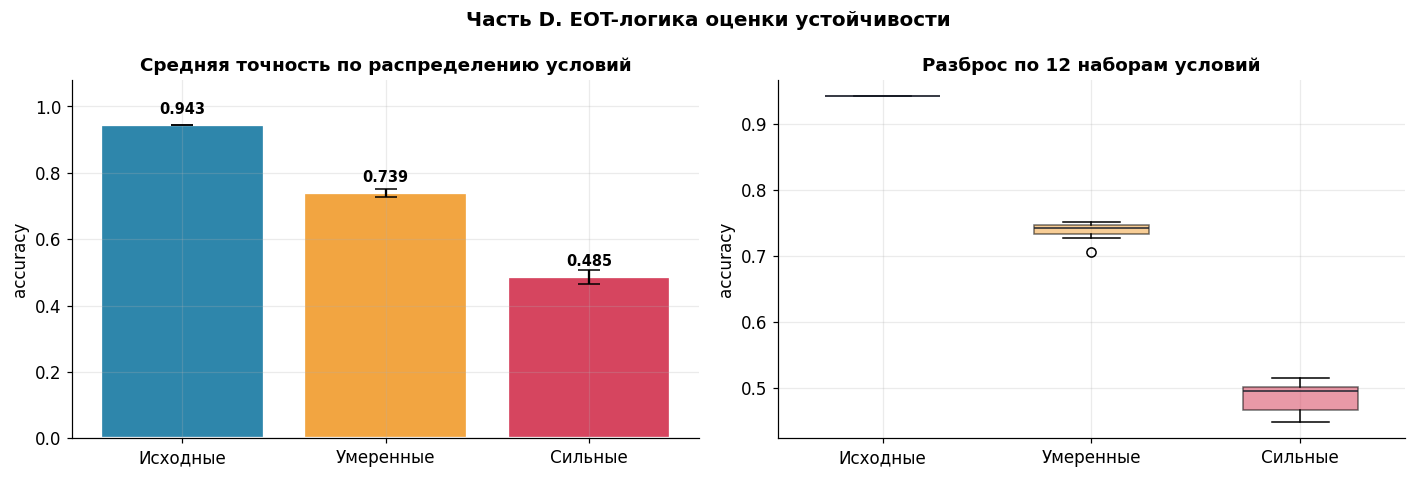

D.3 Исходные   accuracy = 0.943 ± 0.000
D.3 Умеренные  accuracy = 0.739 ± 0.013
D.3 Сильные    accuracy = 0.485 ± 0.021


In [ ]:
REPEATS = 12
regimes = [("Исходные", 0.0, PALETTE["clean"]),
           ("Умеренные", 1.0, PALETTE["mild"]),
           ("Сильные", 1.8, PALETTE["severe"])]

samples = {}
for name, sev, _ in regimes:
    gen = np.random.default_rng(SEED + 1000)
    if sev == 0.0:
        samples[name] = [acc_clean] * REPEATS
    else:
        samples[name] = [accuracy_score(y_test, baseline.predict(flat(transformed_dataset(X_test_img, gen, sev))))
                         for _ in range(REPEATS)]

names = [n for n, _, _ in regimes]
means = [float(np.mean(samples[n])) for n in names]
stds = [float(np.std(samples[n])) for n in names]
colors = [c for _, _, c in regimes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
bars = axes[0].bar(names, means, yerr=stds, capsize=7, color=colors, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, means):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.035, f"{v:.3f}", ha="center", fontsize=9.5, fontweight="bold")
axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("accuracy")
axes[0].set_title("Средняя точность по распределению условий")

bp = axes[1].boxplot([samples[n] for n in names], patch_artist=True, widths=0.55,
                     medianprops=dict(color="#1F2430"))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.55)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].set_ylabel("accuracy"); axes[1].set_title(f"Разброс по {REPEATS} наборам условий")
fig.suptitle("Часть D. EOT-логика оценки устойчивости", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for n, m, s in zip(names, means, stds):
    print(f"D.3 {n:<10} accuracy = {m:.3f} ± {s:.3f}")

**Отчёт по части D.**

| Режим | Средняя accuracy | Стандартное отклонение | Падение относительно `acc_clean` |
|---|---|---|---|
| Исходные | 0.943 | 0.000 | — |
| Умеренные (severity 1.0) | 0.739 | 0.013 | 0.204 |
| Сильные (severity 1.8) | 0.485 | 0.021 | 0.458 |

**Вопрос D.** Почему оценка по одному кадру может завысить устойчивость модели? Как связаны `severity` и стандартное отклонение?

Ответ: один кадр — это одна случайная точка $\theta$ из распределения условий, и результат по ней сильно зависит от удачи. Часть B это наглядно показала: для одного объекта 26° поворота не сменили метку, для другого сменили. Если атакующий или тестировщик проверит модель на одном «удобном» кадре (объект по центру, хороший свет), он получит 0.943 и сделает вывод о надёжности, тогда как в среднем по реалистичным условиям модель верна лишь в 74 % случаев. EOT-оценка заменяет одно значение математическим ожиданием по распределению $\mathcal{D}$, и только оно отражает качество в реальной эксплуатации. Это верно и в обратную сторону: атака, успешная на одном кадре, может не сработать на следующем — поэтому физические патчи оптимизируют по EOT.

Связь `severity` и разброса: чем шире диапазон условий, тем сильнее отличаются друг от друга случайные наборы параметров, тем больше вариативность результата. Разброс вырос с 0 (фиксированные условия) до 0.013 при умеренных и до 0.021 при сильных условиях, то есть при переходе от severity 1.0 к 1.8 примерно в 1.6 раза. Одновременно падает среднее: модель попадает в область, где небольшое изменение условий сильнее меняет решения. Практически это значит, что при сильных условиях нужно больше повторов, чтобы оценка среднего была точной.

## Часть E. Дорожный знак: дистанция и ракурс

**Ваша задача** — построить карту точности в координатах «масштаб × угол» для набора углов
своего варианта и определить границу применимости модели.

In [ ]:
# E.1: углы варианта 1 — от 0 до 32° с шагом 8°
scales = [1.10, 1.00, 0.94, 0.88, 0.82, 0.76]
angles = [0, 8, 16, 24, 32]

# E.2: строки — углы, столбцы — масштабы; фиксированные прочие условия, как в нижнем ряду рисунка
grid = np.zeros((len(angles), len(scales)))
for i, a in enumerate(angles):
    for j, s in enumerate(scales):
        gen = np.random.default_rng(SEED + 7)
        views = np.asarray([physical_transform(im, angle=a, scale=s, brightness=0.95, blur=0.25,
                                               generator=gen) for im in X_test_img])
        grid[i, j] = accuracy_score(y_test, baseline.predict(flat(views)))

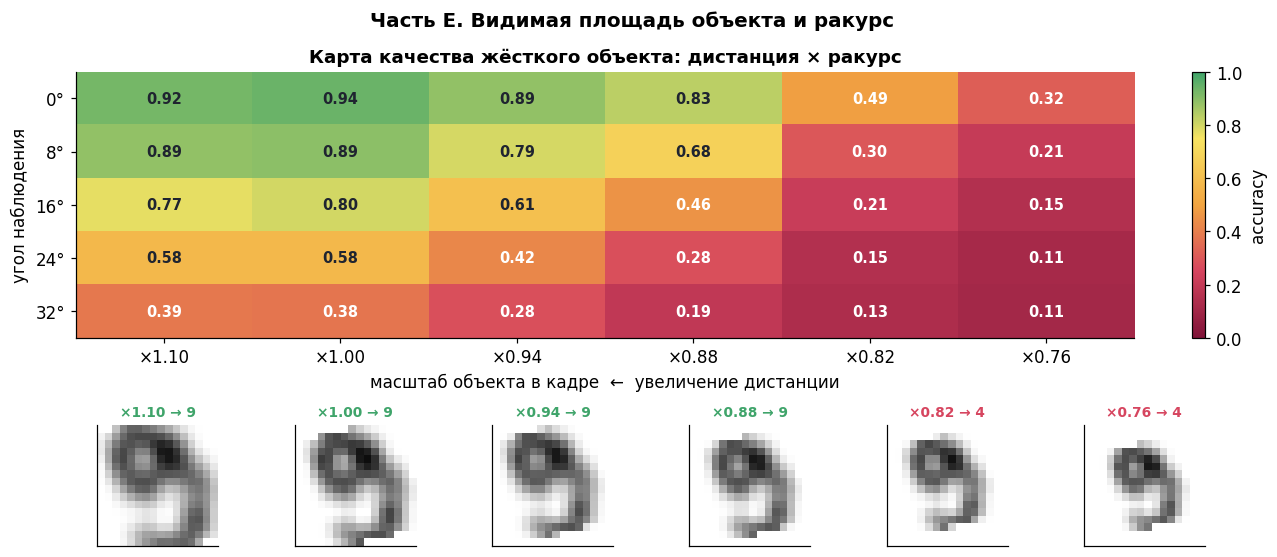

E.3 Режимы с accuracy >= 0.70:
     0°: ×1.10, ×1.00, ×0.94, ×0.88
     8°: ×1.10, ×1.00, ×0.94
    16°: ×1.10, ×1.00
    24°: нет
    32°: нет


In [ ]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, len(scales), height_ratios=[2.2, 1.0], hspace=0.45)

ax = fig.add_subplot(gs[0, :])
im = ax.imshow(grid, cmap=CMAP_HEAT, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scales))); ax.set_xticklabels([f"×{s:.2f}" for s in scales])
ax.set_yticks(range(len(angles))); ax.set_yticklabels([f"{a}°" for a in angles])
ax.set_xlabel("масштаб объекта в кадре  ←  увеличение дистанции")
ax.set_ylabel("угол наблюдения"); ax.grid(False)
ax.set_title("Карта качества жёсткого объекта: дистанция × ракурс")
for i in range(len(angles)):
    for j in range(len(scales)):
        ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="white" if grid[i, j] < 0.55 else "#1F2430")
fig.colorbar(im, ax=ax, fraction=0.03, label="accuracy")

for j, s in enumerate(scales):
    axf = fig.add_subplot(gs[1, j])
    view = physical_transform(example, angle=angles[len(angles) // 2], scale=s, brightness=0.95,
                              blur=0.25, generator=np.random.default_rng(SEED))
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(axf, view)
    axf.set_title(f"×{s:.2f} → {pred}", fontsize=9, fontweight="bold",
                  color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])
fig.suptitle("Часть E. Видимая площадь объекта и ракурс", fontsize=13, fontweight="bold")
plt.show()

mask_ok = grid >= 0.70
print("E.3 Режимы с accuracy >= 0.70:")
for i, a in enumerate(angles):
    ok = [f"×{s:.2f}" for j, s in enumerate(scales) if mask_ok[i, j]]
    print(f"   {a:>3}°: {', '.join(ok) if ok else 'нет'}")

**Отчёт по части E.**

| Показатель | Значение |
|---|---|
| Углы варианта | 0, 8, 16, 24, 32° |
| Максимальная accuracy в карте | **0.939** (0°, ×1.00) |
| Минимальная accuracy в карте | **0.106** (32°, ×0.76) |
| Наибольший допустимый угол при accuracy ≥ 0.70 | **16°** (при масштабе ×1.00: 0.798 и ×1.10: 0.770) |
| Наименьший допустимый масштаб при accuracy ≥ 0.70 | **×0.88** (только при 0°: 0.831) |

Карта полностью (строки — угол, столбцы — масштаб ×1.10 / 1.00 / 0.94 / 0.88 / 0.82 / 0.76):
0°: 0.924 / 0.939 / 0.885 / 0.831 / 0.485 / 0.317; 8°: 0.885 / 0.893 / 0.794 / 0.676 / 0.300 / 0.206; 16°: 0.770 / 0.798 / 0.609 / 0.456 / 0.211 / 0.150; 24°: 0.578 / 0.578 / 0.422 / 0.280 / 0.152 / 0.115; 32°: 0.385 / 0.378 / 0.280 / 0.191 / 0.133 / 0.106.

Два фактора усиливают друг друга: при 0° точность падает ниже 0.70 только на масштабе ×0.82, а при 16° — уже на ×0.94. Область применимости модели — небольшой «угол» карты: ракурс до 16° и масштаб не меньше ×0.88–1.00.

**Вопрос E.** Как связаны видимая площадь знака и успех физической атаки? Чем атака на классификатор отличается от атаки на детектор?

Ответ: видимая площадь объекта уменьшается пропорционально квадрату масштаба (×0.76 — это 58 % исходной площади), а вместе с ней уменьшается и площадь **патча** в пикселях. Патч на большом расстоянии занимает считанные пиксели, размывается оптикой и усредняется при масштабировании, поэтому теряет свою структуру и перестаёт действовать. С другой стороны, как видно по карте, сама модель на малом масштабе и под углом уже работает плохо — и там атака почти не нужна. Поэтому для атакующего есть компромисс: на близком расстоянии патч хорошо виден, но и модель уверена; на далёком модель слабее, но патч неразличим. Физические атаки оптимизируют по EOT на распределении дистанций и углов, чтобы патч работал во всём рабочем диапазоне — как в работе Eykholt et al. по дорожным знакам.

Атака на **детектор** в конвейере автономного вождения сложнее атаки на классификатор. Классификатор получает уже вырезанный и отцентрированный объект и должен ошибиться в одном ответе. Детектор сам ищет объект по всему кадру на множестве масштабов и позиций, выдаёт рамки с уверенностью, и атака должна подавить **все** предложения объекта (или создать ложные) при любой позиции объекта в кадре. Кроме того, в конвейере автомобиля решение принимается по потоку кадров, с трекингом и слиянием данных нескольких датчиков (камера, лидар, радар, карта): чтобы повлиять на поведение машины, атака должна срабатывать стабильно на серии кадров и не противоречить другим источникам. Именно поэтому временная агрегация (часть H) и мультисенсорность — важные защитные меры.

## Часть F. Состязательная одежда: не-жёсткие деформации

**Ваша задача** — реализовать деформацию ткани полем смещений

\[
u(r,c) = A\,\sin\!\big(2\pi f\, r / H\big), \qquad \tilde{x}(r,c) = x\big(r,\; c + u(r,c)\big),
\]

и сравнить деградацию с жёстким поворотом сопоставимой величины.

In [ ]:
def cloth_warp(image, amplitude=1.0, frequency=None, phase=0.0):
    """Не-жёсткая деформация: имитация складок и растяжения ткани."""
    if frequency is None:
        frequency = FREQ
    h, w = image.shape
    rr, cc = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    # F.1: смещение по столбцам зависит от строки — «волны» складок
    shift_c = amplitude * np.sin(2 * np.pi * frequency * rr / h + phase)
    # F.2: поперечное смещение по строкам зависит от столбца, слабее (коэффициент 0.45)
    shift_r = 0.45 * amplitude * np.sin(2 * np.pi * frequency * cc / w + phase)
    # F.3: выборка значений изображения в смещённых координатах
    warped = map_coordinates(image, [rr + shift_r, cc + shift_c], order=1, mode="nearest")
    return np.clip(warped, 0, 1).astype(np.float32)

In [ ]:
amps = [0.0, 0.6, 1.2, 1.8, 2.4, 3.0]

warp_acc, rigid_acc = [], []
for a in amps:
    warped = np.asarray([cloth_warp(im, amplitude=a) for im in X_test_img])
    rotated = np.asarray([physical_transform(im, angle=a * 6) for im in X_test_img])
    warp_acc.append(accuracy_score(y_test, baseline.predict(flat(warped))))
    rigid_acc.append(accuracy_score(y_test, baseline.predict(flat(rotated))))

# сопоставимость величины искажений: среднее смещение пикселя (в пикселях)
rr, cc = np.meshgrid(np.arange(RES), np.arange(RES), indexing="ij")
rad = np.hypot(rr - (RES - 1) / 2, cc - (RES - 1) / 2)
for a, wa, ra in zip(amps, warp_acc, rigid_acc):
    disp_w = np.mean(np.hypot(a * np.sin(2 * np.pi * FREQ * rr / RES),
                              0.45 * a * np.sin(2 * np.pi * FREQ * cc / RES)))
    disp_r = np.mean(rad) * np.deg2rad(a * 6)
    print(f"A={a:.1f}: ткань {wa:.3f} (ср. смещение {disp_w:.2f} пикс) | "
          f"поворот {a * 6:>4.1f}° {ra:.3f} (ср. смещение {disp_r:.2f} пикс)")

A=0.0: ткань 0.943 (ср. смещение 0.00 пикс) | поворот  0.0° 0.943 (ср. смещение 0.00 пикс)
A=0.6: ткань 0.926 (ср. смещение 0.44 пикс) | поворот  3.6° 0.930 (ср. смещение 0.38 пикс)
A=1.2: ткань 0.863 (ср. смещение 0.87 пикс) | поворот  7.2° 0.902 (ср. смещение 0.77 пикс)
A=1.8: ткань 0.776 (ср. смещение 1.31 пикс) | поворот 10.8° 0.870 (ср. смещение 1.15 пикс)
A=2.4: ткань 0.676 (ср. смещение 1.75 пикс) | поворот 14.4° 0.822 (ср. смещение 1.54 пикс)
A=3.0: ткань 0.543 (ср. смещение 2.18 пикс) | поворот 18.0° 0.735 (ср. смещение 1.92 пикс)


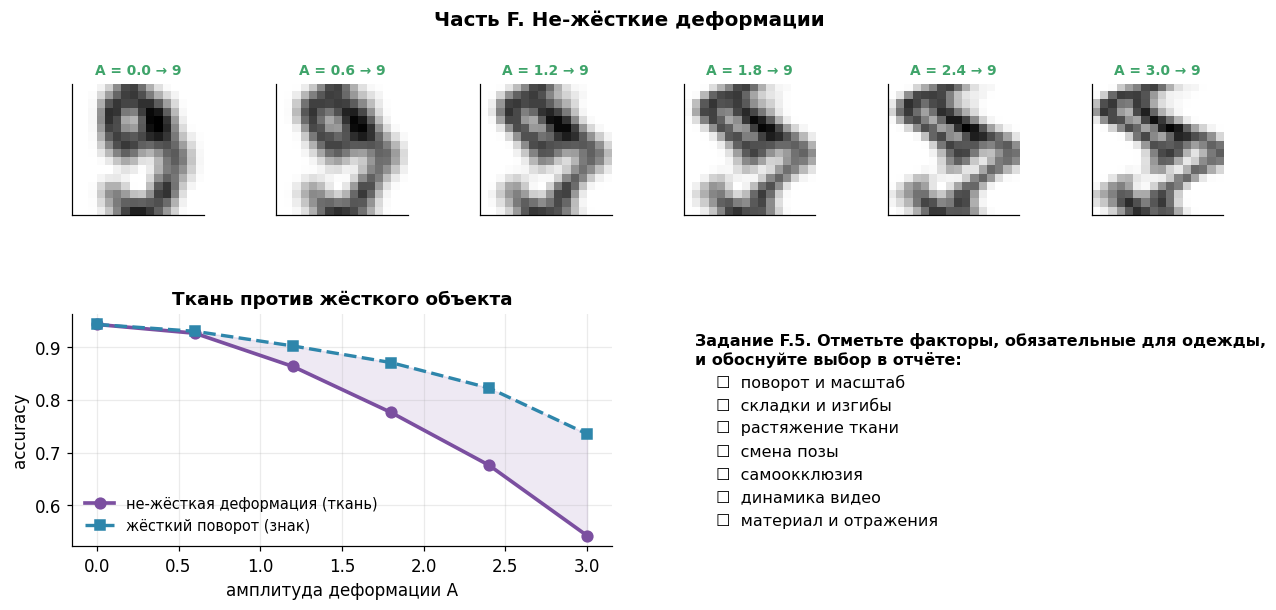

F.6 accuracy при максимальной деформации: ткань 0.543 против жёсткого поворота 0.735


In [ ]:
fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.5], hspace=0.45, wspace=0.55)
for j, a in enumerate(amps):
    ax = fig.add_subplot(gs[0, j])
    view = cloth_warp(example, amplitude=a)
    pred = int(baseline.predict(flat(view[None, ...]))[0])
    show_img(ax, view)
    ax.set_title(f"A = {a:.1f} → {pred}", fontsize=9, fontweight="bold",
                 color=PALETTE["robust"] if pred == true_label else PALETTE["severe"])

ax2 = fig.add_subplot(gs[1, :3])
ax2.plot(amps, warp_acc, "o-", color=PALETTE["accent"], linewidth=2.4, markersize=7,
         label="не-жёсткая деформация (ткань)")
ax2.plot(amps, rigid_acc, "s--", color=PALETTE["clean"], linewidth=2.2, markersize=6,
         label="жёсткий поворот (знак)")
ax2.fill_between(amps, warp_acc, rigid_acc, color=PALETTE["accent"], alpha=0.12)
ax2.set_xlabel("амплитуда деформации A"); ax2.set_ylabel("accuracy")
ax2.set_title("Ткань против жёсткого объекта")
ax2.legend(frameon=False, fontsize=9.5)

ax3 = fig.add_subplot(gs[1, 3:])
ax3.text(0.02, 0.92, "Задание F.5. Отметьте факторы, обязательные для одежды,\n"
                     "и обоснуйте выбор в отчёте:", fontsize=10.5, va="top", fontweight="bold")
items = ["поворот и масштаб", "складки и изгибы", "растяжение ткани", "смена позы",
         "самоокклюзия", "динамика видео", "материал и отражения"]
for k, it in enumerate(items):
    ax3.text(0.06, 0.74 - 0.10 * k, f"☐  {it}", fontsize=10.5, va="top")
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis("off")
fig.suptitle("Часть F. Не-жёсткие деформации", fontsize=13, fontweight="bold")
plt.show()

print("F.6 accuracy при максимальной деформации: "
      f"ткань {warp_acc[-1]:.3f} против жёсткого поворота {rigid_acc[-1]:.3f}")

**Отчёт по части F.**

| A | accuracy (ткань) | accuracy (жёсткий поворот на 6A°) | Разница |
|---|---|---|---|
| 0.0 | 0.943 | 0.943 | 0.000 |
| 1.2 | 0.863 | 0.902 | −0.039 |
| 2.4 | 0.676 | 0.822 | −0.146 |
| 3.0 | 0.543 | 0.735 | **−0.192** |

Величины искажений сопоставимы: при A = 3.0 средний сдвиг пикселя составляет 2.18 пикселя для ткани и 1.92 пикселя для поворота на 18°, то есть почти одинаков, а точность при деформации ткани ниже на 0.192.

**Задание F.5.** Для одежды обязательны все семь факторов из списка, но четыре из них **специфичны именно для одежды**, их нет у жёсткого знака:

- ☑ **складки и изгибы** — рисунок на ткани меняет форму при каждом движении;
- ☑ **растяжение ткани** — меняются пропорции рисунка, у знака пропорции фиксированы;
- ☑ **смена позы** — поворачиваются разные части тела, рисунок виден под разными углами одновременно;
- ☑ **самоокклюзия** — руки и складки перекрывают части рисунка;
- ☑ поворот и масштаб — общие со знаком, но тоже нужны;
- ☑ динамика видео — видеонаблюдение анализирует поток кадров, и рисунок должен работать на каждом;
- ☑ материал и отражения — ткань иначе рассеивает свет, чем гладкий знак, и искажает цвета.

**Вопрос F.** Почему недостаточно учитывать только поворот и масштаб? Какие члены появляются в $\mathcal{D}$?

Ответ: поворот и масштаб — **жёсткие** преобразования: вся картинка сдвигается как целое, соседние пиксели остаются соседями, форма и пропорции сохраняются. Ткань деформируется **нежёстко**: разные участки смещаются по-разному (поле смещений $u(r,c)$ зависит от координат), штрихи изгибаются, соседние элементы расходятся или сближаются. Эксперимент показывает, что такое искажение разрушительнее: при одинаковом среднем сдвиге пикселя (≈2 пикселя) точность под деформацией ткани 0.543 против 0.735 под поворотом. Жёсткое преобразование сохраняет внутреннюю структуру объекта, а именно эту структуру и использует модель; нежёсткое её ломает.

Поэтому для одежды в распределение $\mathcal{D}$ добавляются члены, описывающие нежёсткие деформации: поля складок (частота и амплитуда, как здесь $A$ и `FREQ`), растяжение, кусочно-гладкие искажения (в работе Xu et al. для «adversarial T-shirt» используются TPS-преобразования, thin plate splines), изменение позы, самоокклюзия, а также временная изменчивость в видео. Для жёсткого знака эти члены не нужны: он не гнётся, и достаточно проективного преобразования, освещения и оптики.

## Часть G. Защита: обучение с физически правдоподобными аугментациями

**Ваша задача** — сформировать аугментированную обучающую выборку, обучить вторую модель
и количественно оценить прирост устойчивости и цену на чистых данных.

In [ ]:
aug_gen = np.random.default_rng(SEED + 5)
parts_X, parts_y = [X_train_img], [y_train]
for _ in range(4):                                   # 4 копии со случайными условиями съёмки
    parts_X.append(transformed_dataset(X_train_img, aug_gen, 1.3)); parts_y.append(y_train)
warp_copy = np.asarray([cloth_warp(im, amplitude=float(aug_gen.uniform(0.5, 2.5)),
                                   phase=float(aug_gen.uniform(0, 2 * np.pi)))
                        for im in X_train_img])      # 1 копия с деформацией ткани
parts_X.append(warp_copy); parts_y.append(y_train)
X_aug, y_aug = np.concatenate(parts_X), np.concatenate(parts_y)

# G.2: те же гиперпараметры, что у baseline
robust = LogisticRegression(max_iter=4000, C=0.05, random_state=SEED).fit(flat(X_aug), y_aug)
print("размер аугментированной выборки:", len(X_aug))

размер аугментированной выборки: 7542


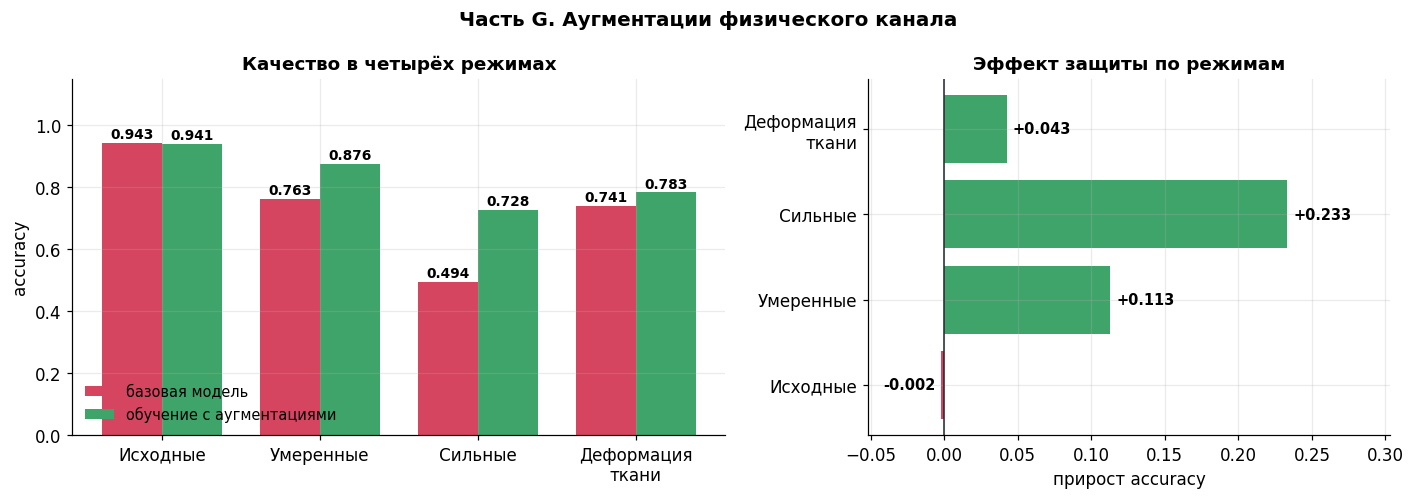

G.3 Размер аугментированной выборки: 7542
    Исходные           база 0.943 → защита 0.941 (-0.002)
    Умеренные          база 0.763 → защита 0.876 (+0.113)
    Сильные            база 0.494 → защита 0.728 (+0.233)
    Деформация ткани   база 0.741 → защита 0.783 (+0.043)


In [ ]:
gen = np.random.default_rng(SEED + 2000)
eval_sets = {
    "Исходные": X_test_img,
    "Умеренные": transformed_dataset(X_test_img, gen, 1.0),
    "Сильные": transformed_dataset(X_test_img, gen, 1.8),
    "Деформация\nткани": np.asarray([cloth_warp(im, amplitude=2.0, frequency=1.6) for im in X_test_img]),
}
base_scores = [accuracy_score(y_test, baseline.predict(flat(v))) for v in eval_sets.values()]
rob_scores = [accuracy_score(y_test, robust.predict(flat(v))) for v in eval_sets.values()]
names_g = list(eval_sets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
xp = np.arange(len(names_g)); wbar = 0.38
b1 = axes[0].bar(xp - wbar / 2, base_scores, wbar, label="базовая модель", color=PALETTE["severe"])
b2 = axes[0].bar(xp + wbar / 2, rob_scores, wbar, label="обучение с аугментациями", color=PALETTE["robust"])
for bs, vs in ((b1, base_scores), (b2, rob_scores)):
    for b, v in zip(bs, vs):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center",
                     fontsize=9, fontweight="bold")
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_g)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("accuracy")
axes[0].set_title("Качество в четырёх режимах")
axes[0].legend(frameon=False, fontsize=9.5, loc="lower left")

delta = np.array(rob_scores) - np.array(base_scores)
b3 = axes[1].barh(names_g, delta,
                  color=[PALETTE["robust"] if d >= 0 else PALETTE["severe"] for d in delta])
for b, d in zip(b3, delta):
    axes[1].text(d + (0.004 if d >= 0 else -0.004), b.get_y() + b.get_height() / 2, f"{d:+.3f}",
                 va="center", ha="left" if d >= 0 else "right", fontsize=9.5, fontweight="bold")
axes[1].axvline(0, color="#1F2430", linewidth=1)
axes[1].set_xlabel("прирост accuracy"); axes[1].set_title("Эффект защиты по режимам")
axes[1].set_xlim(min(delta.min() - 0.05, -0.03), delta.max() + 0.07)
fig.suptitle("Часть G. Аугментации физического канала", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"G.3 Размер аугментированной выборки: {len(X_aug)}")
for n, bs, rs in zip(names_g, base_scores, rob_scores):
    print(f"    {n.replace(chr(10), ' '):<18} база {bs:.3f} → защита {rs:.3f} ({rs - bs:+.3f})")

**Отчёт по части G.** Аугментированная выборка: 1257 исходных + 4 × 1257 со случайными условиями (severity 1.3) + 1257 с деформацией ткани = **7542** изображения.

| Режим | Базовая модель | С аугментациями | Прирост |
|---|---|---|---|
| Исходные | 0.943 | 0.941 | −0.002 |
| Умеренные | 0.763 | 0.876 | **+0.113** |
| Сильные | 0.494 | 0.728 | **+0.233** |
| Деформация ткани (A = 2.0, частота 1.6) | 0.741 | 0.783 | +0.043 |

(Значения «Умеренные» и «Сильные» здесь немного отличаются от части D, так как это другая случайная выборка условий: seed `SEED + 2000`.)

**Вопрос G.** Какова цена робастности?

Ответ: цена на чистых данных — **0.002**, то есть 0.943 → 0.941: одно изображение из 540. При этом в сильных условиях точность выросла на 0.233 (0.494 → 0.728), в умеренных — на 0.113. Обмен крайне выгодный.

Компромисс возникает потому, что при фиксированной ёмкости модели (здесь линейная модель с сильной регуляризацией C = 0.05) веса приходится распределять между двумя задачами: точно разделять идеальные изображения и выдерживать искажённые. Модель, обученная только на идеальных изображениях, может полагаться на тонкие, «хрупкие» признаки (точное положение отдельных пикселей), которые хороши в идеальных условиях, но исчезают при сдвиге или размытии. Аугментации заставляют опираться на более грубые, устойчивые признаки, которые чуть хуже различают классы в идеале, зато сохраняются при искажениях. В нашем случае цена мала, потому что аугментации физически правдоподобны и близки к исходному распределению; при слишком сильных аугментациях или adversarial-обучении против оптимизированных патчей она обычно заметно больше.

Отдельно видно, что для деформации ткани прирост скромный (+0.043): в обучающую выборку входила лишь одна копия с деформацией и другой частотой. Защита работает против тех искажений, которые были представлены в обучении, и слабее переносится на другие.

## Часть H. Видеопоток и временная агрегация

**Ваша задача** — сгенерировать последовательность кадров с эпизодом помехи, сравнить покадровые
решения с агрегированным и оценить, при каком числе кадров агрегация становится надёжной.

In [ ]:
FRAMES = 24
seq_gen = np.random.default_rng(SEED + 33)
occ_window = (RES // 3, RES // 3 + RES // 3, RES // 3, RES - 2, 0.0)

frames, probas, per_frame_pred = [], [], []
for t in range(FRAMES):
    params = sample_params(seq_gen, 1.3)
    occ = occ_window if 9 <= t <= 14 else None       # эпизод помехи на кадрах 9–14
    view = physical_transform(example, **params, occlusion=occ, generator=seq_gen)
    p = baseline.predict_proba(flat(view[None, ...]))[0]
    frames.append(view); probas.append(p); per_frame_pred.append(int(np.argmax(p)))

probas = np.asarray(probas)
# H.3: накопленное среднее вероятностей по кадрам 0..t
cum_mean = np.cumsum(probas, axis=0) / np.arange(1, FRAMES + 1)[:, None]
cum_pred = cum_mean.argmax(axis=1)
cum_conf = cum_mean[:, true_label]
per_frame_conf = probas[:, true_label]

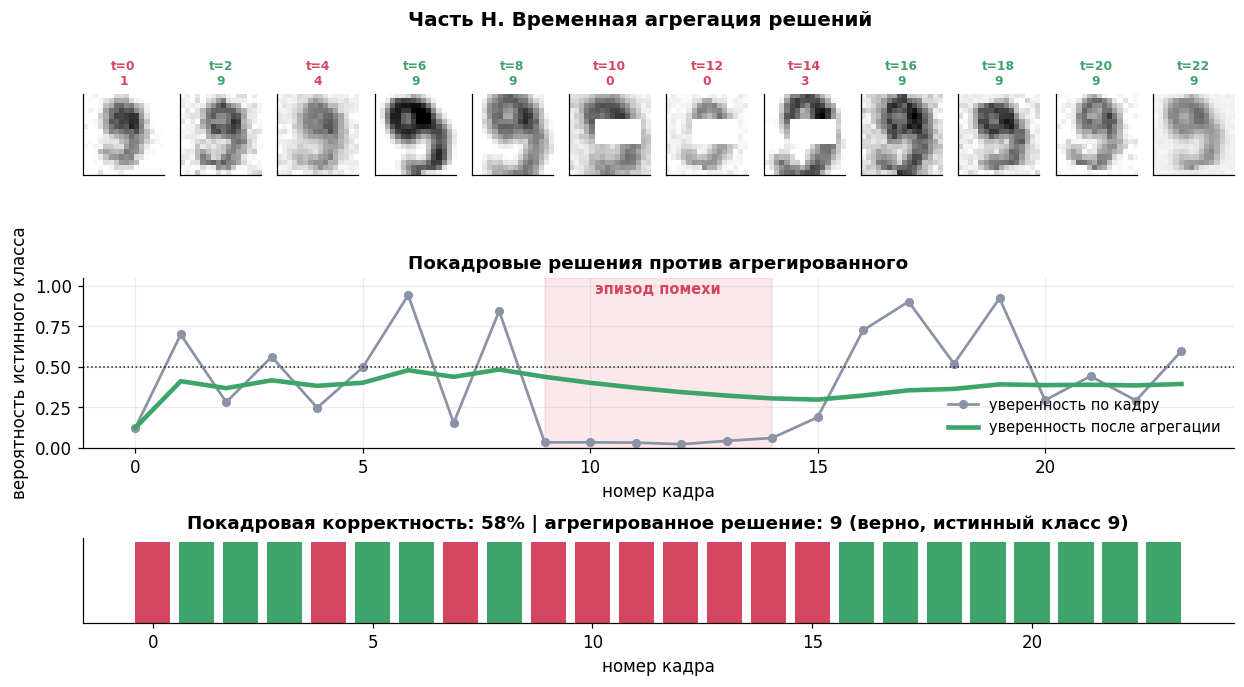

H.4 Покадровая корректность: 0.583
H.5 Агрегированное решение: 9 (истинный класс 9)
H.6 Агрегация стабильно верна начиная с кадра: 1


In [ ]:
frame_acc = float(np.mean([p == true_label for p in per_frame_pred]))
agg_ok = cum_pred[-1] == true_label

fig = plt.figure(figsize=(13.5, 6.4))
gs = fig.add_gridspec(3, 12, height_ratios=[1.0, 1.6, 0.8], hspace=0.75)
for t in range(12):
    ax = fig.add_subplot(gs[0, t])
    show_img(ax, frames[t * 2])
    ok = per_frame_pred[t * 2] == true_label
    ax.set_title(f"t={t*2}\n{per_frame_pred[t*2]}", fontsize=8, fontweight="bold",
                 color=PALETTE["robust"] if ok else PALETTE["severe"])

ax1 = fig.add_subplot(gs[1, :])
ax1.plot(range(FRAMES), per_frame_conf, "o-", color=PALETTE["gray"], linewidth=1.8, markersize=5,
         label="уверенность по кадру")
ax1.plot(range(FRAMES), cum_conf, "-", color=PALETTE["robust"], linewidth=3,
         label="уверенность после агрегации")
ax1.axvspan(9, 14, color=PALETTE["severe"], alpha=0.12)
ax1.text(11.5, 0.95, "эпизод помехи", ha="center", fontsize=9.5, color=PALETTE["severe"], fontweight="bold")
ax1.axhline(0.5, ls=":", color="#1F2430", linewidth=1)
ax1.set_xlabel("номер кадра"); ax1.set_ylabel("вероятность истинного класса"); ax1.set_ylim(0, 1.05)
ax1.set_title("Покадровые решения против агрегированного")
ax1.legend(frameon=False, fontsize=9.5, loc="lower right")

ax2 = fig.add_subplot(gs[2, :])
correct = np.array([p == true_label for p in per_frame_pred])
ax2.bar(range(FRAMES), np.ones(FRAMES),
        color=[PALETTE["robust"] if c else PALETTE["severe"] for c in correct])
ax2.set_yticks([]); ax2.set_xlabel("номер кадра"); ax2.grid(False)
ax2.set_title(f"Покадровая корректность: {frame_acc:.0%} | агрегированное решение: {cum_pred[-1]} "
              f"({'верно' if agg_ok else 'неверно'}, истинный класс {true_label})")
fig.suptitle("Часть H. Временная агрегация решений", fontsize=13, fontweight="bold")
plt.show()

stable_from = next((t for t in range(FRAMES) if all(c == true_label for c in cum_pred[t:])), None)
print(f"H.4 Покадровая корректность: {frame_acc:.3f}")
print(f"H.5 Агрегированное решение: {cum_pred[-1]} (истинный класс {true_label})")
print(f"H.6 Агрегация стабильно верна начиная с кадра: {stable_from}")

**Отчёт по части H.**

| Показатель | Значение |
|---|---|
| Доля верных отдельных кадров | **0.583** (14 из 24) |
| Итоговое агрегированное решение | **9** — верно (истинный класс 9) |
| Номер кадра, с которого агрегация стабильно верна | **1** (усреднение вероятностей) |

## Часть I. Итоговый анализ

### Сводная таблица результатов (вариант 1, `SEED = 42`, `RES = 16`)

| Режим | accuracy | Падение относительно `acc_clean` | Комментарий |
|---|---|---|---|
| Идеальные условия | 0.943 | — | Оценка только в одной точке распределения условий |
| Умеренные условия | 0.739 ± 0.013 | 0.204 | Реалистичные вариации съёмки: теряется пятая часть точности |
| Сильные условия | 0.485 ± 0.021 | 0.458 | Модель верна менее чем в половине случаев |
| Локальный маркер, худшая позиция | 0.674 | 0.269 | Маркер на 9.8 % кадра в информативной области; в лучшей позиции — 0.926 |
| Максимальная дистанция и ракурс | 0.106 | 0.837 | 32° и ×0.76: практически случайное угадывание (0.1) |
| Максимальная деформация ткани | 0.543 | 0.400 | Хуже жёсткого поворота сопоставимой силы (0.735) |
| Аугментации, сильные условия | 0.728 | 0.215 | +0.233 к базовой модели при цене 0.002 на чистых данных |
| Агрегация кадров | итог верен (1.0 по решению) | — | Отдельные кадры верны лишь в 58.3 % случаев |

### Выводы

1. **Цифровая точность не определяет физическую устойчивость.** При `acc_clean = 0.943` точность при умеренных условиях съёмки составила 0.739, при сильных — 0.485, а на краю карты «дистанция × ракурс» — 0.106. Одна и та же модель на одних и тех же объектах теряет от 20 до 84 процентных пунктов только из-за канала наблюдения.
2. **Для локального возмущения положение важно не меньше площади.** Маркер одного размера (9.8 % кадра) снижает точность до 0.674 в худшей позиции и лишь до 0.926 в лучшей — разница 0.252. Порог accuracy 0.5 достигается при ≈ 21.7 % площади в центре. Компактная форма опаснее полосы той же площади (0.674 против 0.756–0.780).
3. **Факторы съёмки усиливают друг друга.** Без поворота модель держит accuracy ≥ 0.70 до масштаба ×0.88, а при 16° — только до ×1.00; при 24° и более допустимых режимов нет. Область применимости — узкий угол карты, её надо указывать явно в требованиях к системе.
4. **Нежёсткие деформации опаснее жёстких.** При сопоставимом среднем сдвиге пикселя (≈ 2 пикселя) деформация ткани даёт 0.543, поворот — 0.735. Поэтому модели угроз для одежды обязательно включают складки, растяжение, позу и самоокклюзию.
5. **Физически правдоподобные аугментации — дешёвая и эффективная защита.** Прирост +0.233 в сильных условиях и +0.113 в умеренных при потере всего 0.002 на чистых данных. Против деформаций ткани, слабо представленных в обучении, прирост меньше (+0.043): защита переносится только на знакомые искажения.
6. **Временная агрегация превращает ненадёжные кадры в надёжное решение.** Отдельные кадры верны в 58.3 % случаев, но усреднение вероятностей даёт верный ответ уже с кадра 1 и выдерживает эпизод окклюзии на шести кадрах; голосование стабилизируется на кадр позже.
7. **Оценка устойчивости по одному кадру или объекту недостоверна.** На пяти разных объектах один и тот же набор условий даёт от 0 до 4 смен метки, а разброс точности растёт с силой условий (0.013 → 0.021). Корректна только EOT-оценка по распределению условий и по выборке объектов.

### Контрольные вопросы

**1. Почему ограничения $\|\delta\|_p \le \varepsilon$ недостаточно для описания физической атаки?**
Норма ограничивает изменение **входного тензора**, а физический атакующий меняет **объект в сцене**, который затем проходит через канал съёмки $T_\theta$. Физический патч, наоборот, большой по норме (внутри маски пиксели меняются как угодно), но ограничен по площади и положению, печатаемости цветов и естественности. Кроме того, один и тот же объект даёт множество разных входов при разных $\theta$: ограничение надо ставить на объект, а успех требовать в среднем по распределению условий — это и есть EOT-постановка.

**2. Чем отличаются ASR и robust ASR и почему второй, как правило, ниже?**
ASR — доля успеха атаки на фиксированных входах (один ракурс, одно освещение). Robust ASR — доля успеха, усреднённая по распределению преобразований $\mathcal{D}$ (разные дистанции, углы, свет, кадры). Он ниже, потому что возмущение, оптимальное для одного вида объекта, частично разрушается поворотом, масштабом, размытием и шумом: атака должна сработать не в одной точке, а во всей области условий. Аналогично в работе точность модели под «идеальным» маркером и та же точность, усреднённая по условиям, различаются.

**3. Как площадь и положение патча влияют на эффективность? Числа из части C.**
С ростом площади точность падает монотонно: 1.6 % кадра → 0.941, 6.2 % → 0.831, 9.8 % → 0.785, 25 % → 0.422, 47 % → 0.189; уровень 0.5 — около 21.7 %. При одинаковой площади 9.8 % положение меняет результат от 0.674 (позиция (4, 10), информативная область) до 0.926 (позиция (0, 4), край кадра) — разница 0.252. Эффективен патч, накрывающий признаки, на которые опирается модель.

**4. Почему атака на детектор сложнее атаки на классификатор?**
Детектор ищет объект по всему кадру в множестве позиций и масштабов и выдаёт много кандидатов; атака должна подавить их все или все сдвинуть. Классификатор принимает один уже вырезанный объект и требует одного неверного ответа. Кроме того, детектор в реальной системе работает на потоке кадров с трекингом и часто с другими датчиками, так что атака должна быть стабильна во времени и согласована с ними.

**5. Какие члены распределения $\mathcal{D}$ обязательны для одежды и не нужны для жёсткого знака?**
Нежёсткие деформации (складки, изгибы, растяжение ткани), смена позы и движение человека, самоокклюзия (руками, складками), свойства материала (рассеяние света, искажение цвета при печати на ткани), временная изменчивость в видео. Для знака достаточно проективного преобразования (ракурс, дистанция), освещения, оптики и шума.

**6. Почему временная агрегация помогает, но не является полной защитой?**
Она усредняет независимые ошибки: случайные неудачные кадры (помеха, блик, окклюзия) не перевешивают большинство верных. В работе при 58.3 % верных кадров итог верен, и эпизод помехи на кадрах 9–14 не изменил решения. Но если атака действует **устойчиво** на всех кадрах (EOT-патч, рассчитанный на весь диапазон условий), ошибки не случайны и коррелированы: агрегация усреднит их и уверенно выдаст неверный ответ. Кроме того, агрегация вносит задержку, что критично для систем реального времени, и не помогает в ситуациях, где решение нужно по одному кадру.

**7. Как корректно измерять цену робастности и почему нельзя ограничиваться одним режимом?**
Цену робастности нужно измерять как разницу точности защищённой и базовой модели на **чистых** данных (здесь 0.002) и одновременно указывать прирост во **всех** релевантных режимах: умеренных (+0.113), сильных (+0.233), деформациях ткани (+0.043). По одному режиму можно получить ложную картину: защита может сильно помогать против одного вида искажений и почти не помогать против другого, как видно по разнице +0.233 и +0.043. Оценки должны быть EOT-усреднёнными (много наборов условий, фиксированные seed), с указанием разброса, чтобы различия не были шумом.

### Дополнительные задания

Выполнено: маркер несимметричной формы (см. ниже).

- Заменить `LogisticRegression` на `MLPClassifier` и повторить части D, E, G. Изменился ли характер деградации?
- Добавить в часть C маркер несимметричной формы (полоса) и сравнить с квадратом равной площади.
- Добавить в `cloth_warp` второе поперечное поле смещений с независимой частотой.
- Прогнать работу для двух дополнительных значений `SEED` и оценить устойчивость выводов.
- Реализовать простейший детектор аномальной локальной области и проверить его на данных части C.

### Чек-лист сдачи

- [ ] Заполнен паспорт работы и указан номер варианта.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях B, C, D, E, F, G, H.
- [ ] В части B достигнуто не менее двух смен предсказанной метки.
- [ ] Заполнены все таблицы отчёта числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–7.
- [ ] Сформулировано не менее пяти выводов.
- [ ] Все графики подписаны и читаемы.

### Критерии оценивания

| Критерий | Баллов |
|---|---|
| Части A и B: стенд и физический канал | 15 |
| Часть C: локальность патча | 15 |
| Часть D: EOT-оценка | 15 |
| Часть E: карта дистанция × ракурс | 15 |
| Часть F: не-жёсткие деформации | 10 |
| Часть G: защита аугментациями | 15 |
| Часть H: временная агрегация | 5 |
| Выводы и контрольные вопросы | 10 |
| **Итого** | **100** |

Дополнительные задания повышенной сложности: до 20 баллов сверх основной суммы.

### Литература

- Brown T. et al. Adversarial Patch (2017): <https://arxiv.org/abs/1712.09665>
- Eykholt K. et al. Robust Physical-World Attacks on Deep Learning Visual Classification (2018): <https://arxiv.org/abs/1707.08945>
- Athalye A. et al. Synthesizing Robust Adversarial Examples (2018): <https://arxiv.org/abs/1707.07397>
- Xu K. et al. Adversarial T-shirt! Evading Person Detectors in a Physical World (2020): <https://arxiv.org/abs/1910.11099>
- Thys S. et al. Fooling automated surveillance cameras (2019): <https://arxiv.org/abs/1904.08653>